# **REDES CONVOLUCIONAIS APLICADAS A CLASSIFICAÇÃO DE IMAGEM**

O treinamento de modelos profundos com *backpropagation* tem sido desenvolvido de diversas maneiras desde, pelo menos, 1990. Mesmo com isso, um ponto importante para o *Deep Learning* foi em 2012, quando a **AlexNet** foi publicada. Ela obteve uma pontuação significativamente melhor do que qualquer outro concorrente no desafio de classificação *ImageNet* e contribuiu muito para popularizar o *DL*. A **AlexNet** é uma rede de oito camadas e usa camadas convolucionais, que foram introduzidas por Fukushima (1980) e posteriormente usadas na *LeNet*. As camadas convolucionais e as redes neurais convolucionais (CNNs) resultantes são blocos de construção importantes no *DL*.

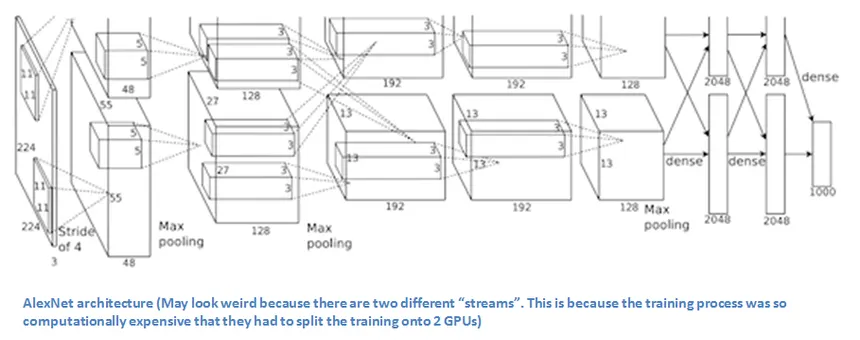 *Arquitetura da AlexNet*

## **O DATASET CIFAR-10**

O dataset **CIFAR-10** consiste em 60.000 imagens de treinamento e 10.000 de teste, cada uma pertencente a uma de dez categorias: avião, automóvel, pássaro, gato, cervo, cão, sapo, cavalo, navio e caminhão. Cada imagem tem 32x32 pixels. Embora possa parecer similar ao *MNIST*, o *CIFAR-10* é mais desafiador, pois consiste em imagens coloridas de objetos do cotidiano que são muito mais diversos.

### Explorando o dataset

Category:  [8]


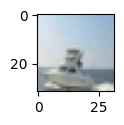

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import logging
tf.get_logger().setLevel(logging.ERROR)

#Carregando o dataset CIFAR-10 e exibindo uma imagem de exemplo, nesse caso a imagem de índice 100
cifar_dataset = keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar_dataset.load_data()
print('Category: ', train_labels[100])
plt.figure(figsize=(1, 1))
plt.imshow(train_images[100])
plt.show()

In [6]:
#Exibindo as dimensões dos dados de treinamento
print('Shape of training images: ', train_images.shape)
print('Shape of training labels: ', train_labels.shape)

#Exibindo os valores do canal RGB da imagem de índice 100
print(train_images[100][0][0])

Shape of training images:  (50000, 32, 32, 3)
Shape of training labels:  (50000, 1)
[213 229 242]


## **CARACTERÍSTICAS DAS CAMADAS CONVOLUCIONAIS**

Uma propriedade fundamental das camadas convolucionais é a **invariância à translação**. No caso da classificação de objetos em uma imagem, isso significa que mesmo que um objeto seja deslocado (transladado) horizontal ou verticalmente para uma posição diferente na imagem, a rede ainda será capaz de reconhecê-lo. Isso ocorre independentemente da posição que esse objeto se encontrava nos dados de treinamento. A invariância à translação é ocorre graças ao **compartilhamento de pesos** entre os neurônios e ao torná-los **esparsamente conectados**.

As camadas *fully connected* que estudamos até agora eram todas organizadas em uma única dimensão, como um *array* de neurônios. Porém, a camada convolucional tem uma estrutura diferentes, onde os neurônios estão organizado em três dimensões.

Duas das dimensões (altura e largura) correspondem à natureza 2D da entrada, já que é uma imagem. Além disso, há uma terceira dimensão em que os neurônios são armazenados em **canais** ou **mapas de features (feature maps)**

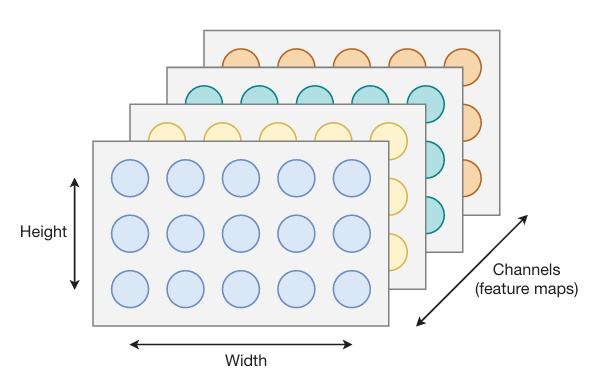 *Representação dessa estrutura das camadas convolucionais.*

Assim como em uma camada *fully connected* normal, não há conexões entre os neurônios dentro de uma camada convolucional. No entanto, todos os neurônios dentro de um único canal possuem pesos identicos (**compartilhamento de pesos**), isso é representado na imagem pela cor igual de todos os neurônios da mesma camada, mas eles receberão valores de entrada diferentes.

Ao descrever uma camada convolucional, usamos um identificador de padrões, conhecido como **kernel** ou **matriz de convolução**, como o menor bloco de construção.

**A operação de convolução** consiste em multiplicar os valores do *kernel* pelos valores originais dos pixels da imagem e, em seguida, somar os resultados. A matriz de saída desse processo é conhecida como **feature map**.

![Convolution gif](2D_Convolution_Animation.gif) *Gif que mostra o processo de convolução*

Outro termo importante é ***stride***, que é o "passo", ou seja, o número de pixels que o *kernel* irá se deslocar pela imagem de entrada. *Não é recomendado um stride de dimensão maior que o kernel, pois, se isso acontecer, neurônios serão "esquecidos" durante o treinamento.* Mesmo com o *stride* de 1, o número de neurônios resultantes no *feature map* é ligeiramente menor que o número de pixels. Isso pode ser resolvido primeiro preenchendo a imagem com zeros ao redor das bordas (**padding**), de modo que o centro dos neurônios de borda e de canto acabe centrado sobre os pixels de borda e de canto.

*Obs: uma indicação de material para entender melhor esses conceitos: [CNN Explainer](https://poloclub.github.io/cnn-explainer/)*

Os canais em que os neurônios estão da camada convolucional agora cria algo chamado de mapa de *features* para a imagem. Cada neurônio atuará como um identificador de *feature* (padrão) e "disparará" se a *feature* particular for encontrada na localização coberta pelo campo receptivo, região de pixels que um neurônio recebe como entrada, daquele neurônio. Por exemplo, se os pesos do neurônio deram a ele a capacidade identificar uma linha vertical, então, se houver uma longa linha vertical na imagem, todos os neurônios que estão centrados nesta linha vertical dispararão. Dado que todos os neurônios no mapa usam pesos idênticos, não importa onde em uma imagem uma feature apareça. O mapa de *features* será capaz de identificá-la independentemente da localização. Esta é a origem da propriedade de **invariância à translação**.

Outra coisa importante de comentar, cada neurônio não recebe entradas de todos os pixels da imagem, ou seja, não é uma rede *fully connected*, mas é esparsamente conectada. Claramente, isso é benéfico do ponto de vista da eficiência, porque menos conexões levarão a menos cálculos.

A capacidade de detectar apenas uma única *feature*, como uma linha vertical, seria muito limitante. Para classificar diferentes tipos de objetos, a rede também precisa ser capaz de identificar outros tipos de padrões. Isso é resolvido organizando a camada convolucional em múltiplos canais ou mapas de features (feature maps). Ou seja, de forma similar a como descrevemos que uma imagem tem três canais (cada um correspondendo a uma cor), uma camada convolucional tem múltiplos canais de saída. Cada canal corresponde a uma *feature* específica, como uma linha vertical, uma linha horizontal, uma linha diagonal ou uma mancha roxa.

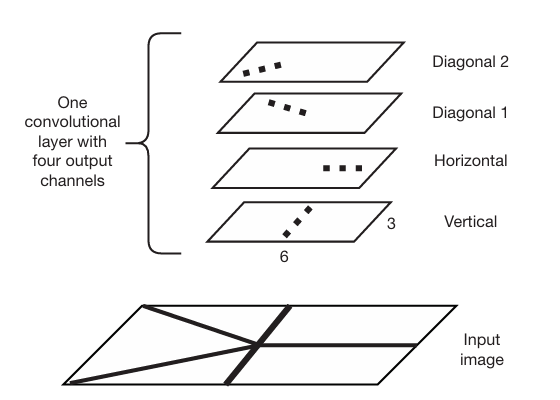 *Exemplo de uma camada convolucional com 4 canais e 18 neurônios em cada canal. Cada um dos canais é responsável pela identificação de uma feature.*

Todos os canais em uma única camada convolucional têm o mesmo número de neurônios, e todos os neurônios em um canal compartilham pesos uns com os outros. No entanto, canais diferentes na mesma camada têm pesos diferentes. Embora eu tenha falado sobre features explícitas que os canais identificarão, como linhas horizontais, verticais e diagonais, não precisamos definir explicitamente essas features. A rede aprenderá quais features procurar durante o processo de treinamento.

## **HANDS-ON: CLASSIFICAÇÃO DE IMAGENS COM CNN**

A *CNN* que construirei consistirá em duas camadas convolucionais seguidas por uma única camada *fully connected*. A primeira camada convolucional possui 64 canais e 256 neurônios por canal, sendo dispostos da seguinte maneira 16x16, o tamanho do *kernel* é 5x5 e o *stride* de 2x2. A segunda camada convolucional também possui 64 canais, mas só 64 neurônios por canal (8x8), o tamanho do *kernel* é 3x3 e o *stride* de 2x2. A camada *fully connected* tem um canal só (obviamente) com 10 neurônios, cada um representando uma classe de saída .

### Código de inicialização para a rede

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Dropout
import numpy as np
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 128
BATCH_SIZE = 32

#Carregando o dataset CIFAR-10
cifar_dataset = keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar_dataset.load_data()

#Normalizando os dados
mean = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images = (test_images - mean) / stddev

print('Média: ', mean)
print('Desvio padrão: ', stddev)

#Convertendo as labels para *one-hot encoding*
train_labels = to_categorical(train_labels, num_classes=10)
test_labels = to_categorical(test_labels, num_classes=10)

Média:  120.70756512369792
Desvio padrão:  64.1500758911213


### Criando e treinando a CNN

In [ ]:
#Definindo a arquitetura da CNN com duas camadas convolucionais e uma camada *fully connected*
model = Sequential()
model.add(Conv2D(64, (5,5), strides=(2,2), activation='relu', padding='same', 
                 input_shape=(32, 32, 3), kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(Conv2D(64, (3,3), strides=(2,2), activation='relu', padding='same', 
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(Flatten())
model.add(Dense(10, activation='softmax', kernel_initializer='glorot_uniform', bias_initializer='zeros'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), 
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2, shuffle=True)

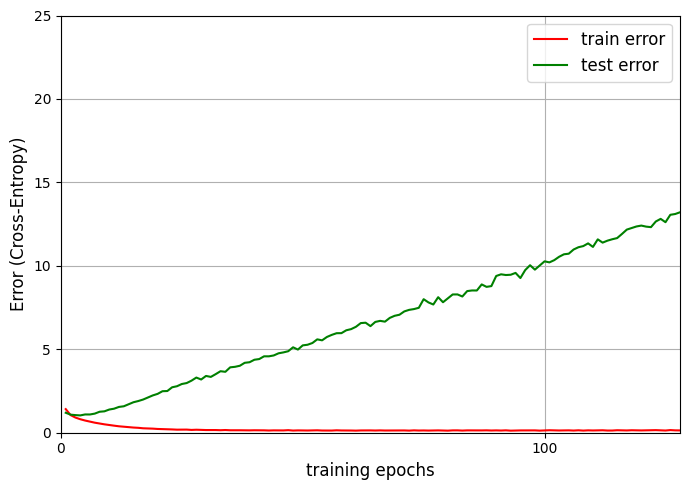

In [11]:
import matplotlib.pyplot as plt

#Obtenha a perda de treinamento e validação do objeto history
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

#Plotar o erro de treinamento e validação
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, loss, color='red', label='train error') 
plt.plot(epochs_range, val_loss, color='green', label='test error')

#Rótulos dos eixos
plt.xlabel('training epochs', fontsize=12)
plt.ylabel('Error (Cross-Entropy)', fontsize=12) 
plt.ylim(0, 25)
plt.yticks(range(0, 26, 5)) 

plt.xlim(0, EPOCHS) 
plt.xticks(range(0, EPOCHS + 1, 100))
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show() # Mostrar o gráfico

A partir do gráfico acima, nota-se que a rede não está conseguindo generalizar bem, ela está sofrendo com *overfitting*, para ver isso, basta olhar o crescimento da *loss* de teste em comparação com a de treino.

**Loss final:**

loss de treino = **0.1386**

loss de teste = **13.2091**

#### Novas configurações para rede

##### Configuração 2

In [ ]:
#Definindo a arquitetura da CNN com duas camadas convolucionais e uma camada *fully connected*
model = Sequential()
model.add(Conv2D(64, (3,3), strides=(2,2), activation='relu', padding='same', 
                 input_shape=(32, 32, 3), kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(Conv2D(16, (2,2), strides=(2,2), activation='relu', padding='same', 
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(Flatten())
model.add(Dense(10, activation='softmax', kernel_initializer='glorot_uniform', bias_initializer='zeros'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), 
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2, shuffle=True)

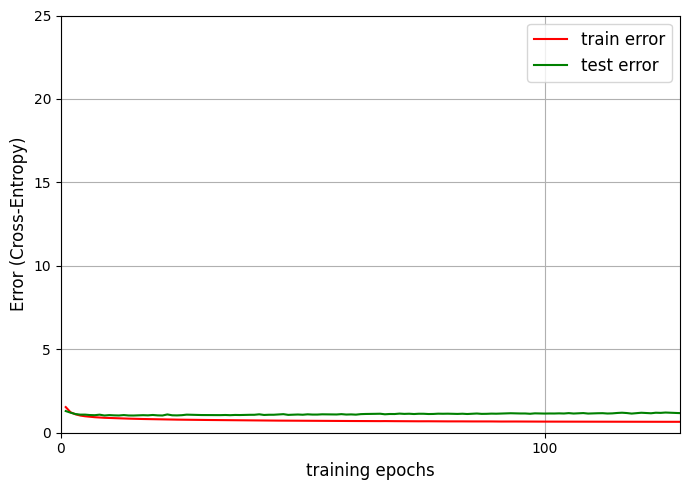

In [13]:
import matplotlib.pyplot as plt

#Obtenha a perda de treinamento e validação do objeto history
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

#Plotar o erro de treinamento e validação
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, loss, color='red', label='train error') 
plt.plot(epochs_range, val_loss, color='green', label='test error')

#Rótulos dos eixos
plt.xlabel('training epochs', fontsize=12)
plt.ylabel('Error (Cross-Entropy)', fontsize=12) 
plt.ylim(0, 25)
plt.yticks(range(0, 26, 5)) 

plt.xlim(0, EPOCHS) 
plt.xticks(range(0, EPOCHS + 1, 100))
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show() # Mostrar o gráfico

Nesse caso da imagem acima, o índicio de *overfitting* não é tão forte, devido a curva pouco crescente. Porém, enquanto a *loss* de teste cresce a de treino diminui.

**Loss final:**

loss de treino = **0.6538**

loss de teste = **1.1744**

##### Configuração 3

In [ ]:
#Definindo a arquitetura da CNN com duas camadas convolucionais e uma camada *fully connected*
model = Sequential()
model.add(Conv2D(64, (3,3), strides=(2,2), activation='relu', padding='same', 
                 input_shape=(32, 32, 3), kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(Dropout(0.20))  #Adicionando uma camada de dropout
model.add(Conv2D(16, (2,2), strides=(2,2), activation='relu', padding='same', 
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(Dropout(0.20))  #Adicionando uma segunda camada de dropout
model.add(Flatten())
model.add(Dense(10, activation='softmax', kernel_initializer='glorot_uniform', bias_initializer='zeros'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), 
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2, shuffle=True)

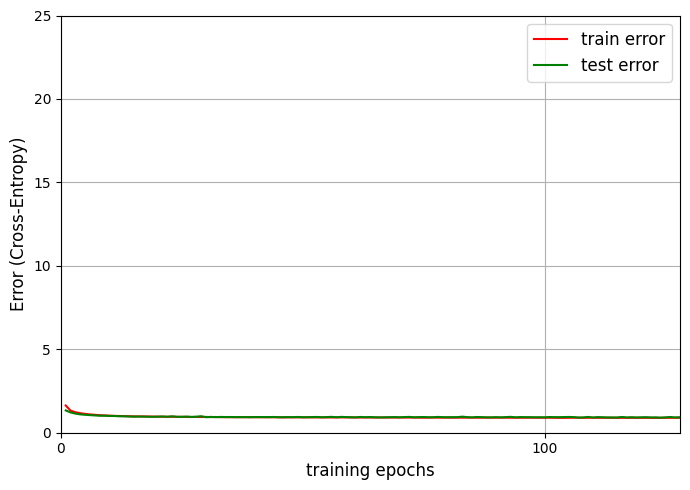

In [17]:
import matplotlib.pyplot as plt

#Obtenha a perda de treinamento e validação do objeto history
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

#Plotar o erro de treinamento e validação
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, loss, color='red', label='train error') 
plt.plot(epochs_range, val_loss, color='green', label='test error')

#Rótulos dos eixos
plt.xlabel('training epochs', fontsize=12)
plt.ylabel('Error (Cross-Entropy)', fontsize=12) 
plt.ylim(0, 25)
plt.yticks(range(0, 26, 5)) 

plt.xlim(0, EPOCHS) 
plt.xticks(range(0, EPOCHS + 1, 100))
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show() # Mostrar o gráfico

**Loss final:**

loss de treino = **0.8964**

loss de teste = **0.9281**